 Match Duration Analysis: Best of 3 vs Best of 5 Matches
 
 -> This analysis compares the average duration of matches based on match format.
It helps understand how match length changes between Best of 3 and Best of 5 formats and highlights the endurance demands placed on players.

In [1]:
import pandas as pd
matches_copy=pd.read_csv("/Users/ssweeti/Desktop/Tennis-project_EDA/tennis_atp-master/matches_cleaned.csv")

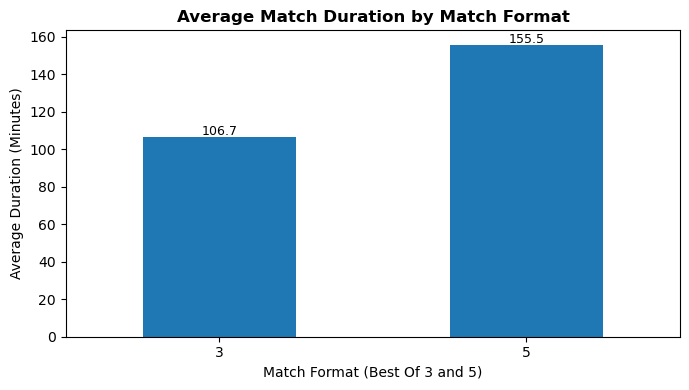

In [2]:
import matplotlib.pyplot as plt

# Calculate average match duration by match format
avg_duration_by_format = (
    matches_copy
    .groupby("best_of")["minutes"]
    .mean()
    .sort_index()
)

# Create bar plot
plt.figure(figsize=(7, 4))
ax = avg_duration_by_format.plot(kind="bar")

# Titles and labels
plt.title("Average Match Duration by Match Format", fontsize=12, fontweight="bold")
plt.xlabel("Match Format (Best Of 3 and 5)")
plt.ylabel("Average Duration (Minutes)")
plt.xticks(rotation=0)

# Add value labels on bars
for i, value in enumerate(avg_duration_by_format):
    ax.text(i, value + 1, f"{value:.1f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


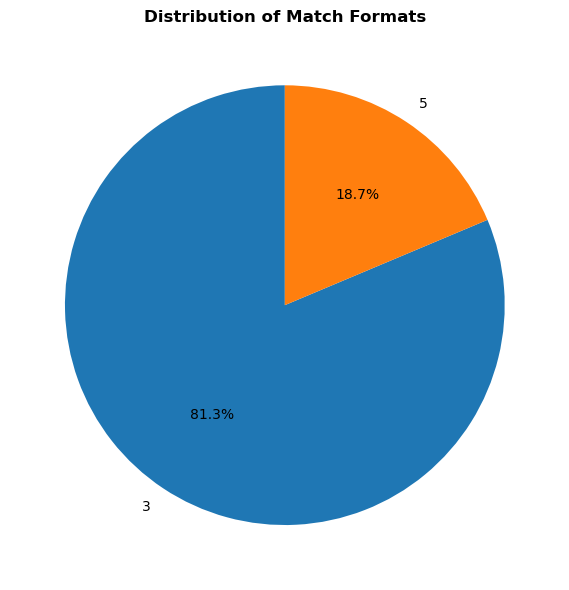

In [3]:
import matplotlib.pyplot as plt

# Count match format distribution
match_format_distribution = matches_copy["best_of"].value_counts().sort_index()

# Create pie chart
plt.figure(figsize=(6, 6))
ax = match_format_distribution.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10}
)

# Title and formatting
plt.title("Distribution of Match Formats", fontsize=12, fontweight="bold")
plt.ylabel("")  # Remove default y-label

plt.tight_layout()
plt.show()


Performance Comparison: Top Players in Best of 3 vs Best of 5 Matches

->This analysis compares how top-performing players perform across different match formats.
It helps identify whether elite players maintain consistency in both Best of 3 and Best of 5 matches.

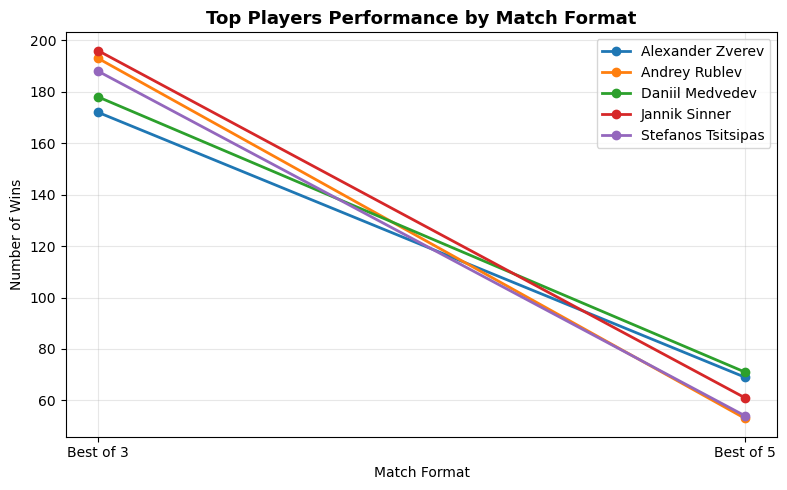

In [4]:
import matplotlib.pyplot as plt

# Select Top 5 players
top_players = matches_copy["winner_name"].value_counts().head(5).index

# Filter dataset for those players
format_data = matches_copy[matches_copy["winner_name"].isin(top_players)]

# Count wins by player and match format
format_performance = (
    format_data.groupby(["winner_name", "best_of"])
    .size()
    .unstack(fill_value=0)
)

# Rename columns for clarity
format_performance.columns = [f"Best of {int(col)}" for col in format_performance.columns]

# Plot line chart
plt.figure(figsize=(8,5))

for player in format_performance.index:
    plt.plot(
        format_performance.columns,
        format_performance.loc[player],
        marker="o",
        linewidth=2,
        label=player
    )

plt.title("Top Players Performance by Match Format",
          fontsize=13, fontweight="bold")
plt.xlabel("Match Format")
plt.ylabel("Number of Wins")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
